<a href="https://colab.research.google.com/github/kessa8691-sudo/kidney-stone-detector/blob/main/ultra160.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- STEP 1: BRING IN THE TOOLS ---
# We are getting 'kagglehub' to download the data
import kagglehub
# 'os' helps the computer look inside folders
import os
# 'matplotlib' is our robot's "eyes" so it can show us the pictures on the screen!
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Step 1 Complete: Tools are ready!\n")

# --- STEP 2: DOWNLOAD THE DATA ---
print("Downloading Kidney Stone ultrasound pictures...")
# This saves the pictures to the Colab computer
kidney_path = kagglehub.dataset_download("imtkaggleteam/kidney-stone-classification-and-object-detection")
print("Done! Kidney dataset saved in this folder:", kidney_path)

print("\nDownloading Baby (Fetus) ultrasound pictures...")
fetus_path = kagglehub.dataset_download("orvile/ultrasound-fetus-dataset")
print("Done! Baby dataset saved in this folder:", fetus_path)

print("\nStep 2 Complete: We have the pictures!")

Step 1 Complete: Tools are ready!



100%|██████████| 215M/215M [00:02<00:00, 82.8MB/s]

Extracting files...


Done! Kidney dataset saved in this folder: /root/.cache/kagglehub/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection/versions/1



100%|██████████| 604M/604M [00:03<00:00, 182MB/s]

Extracting files...


Done! Baby dataset saved in this folder: /root/.cache/kagglehub/datasets/orvile/ultrasound-fetus-dataset/versions/2

Step 2 Complete: We have the pictures!


Looking for a picture to show you...
Found a picture! Opening it now...


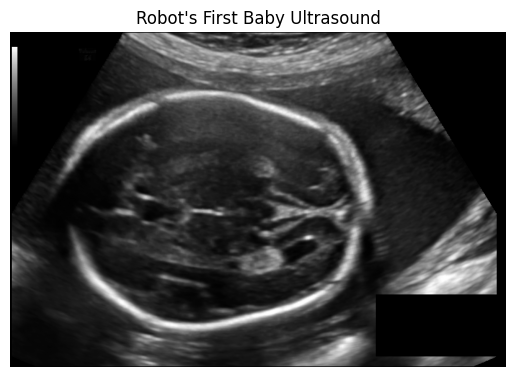

In [2]:
# --- STEP 3: PEEK INSIDE THE FOLDER ---

# Let's look inside the Baby folder we just downloaded
# (Note: Folders usually have smaller folders inside them. We are guessing the name here,
# but usually it's something like 'images' or 'train')
print("Looking for a picture to show you...")

# We use os.walk to search through all the folders we downloaded
image_to_show = None

for root, folders, files in os.walk(fetus_path):
    for file in files:
        # We only want to look at pictures (like .jpg or .png)
        if file.endswith(".jpg") or file.endswith(".png"):
            # We found one! Let's save its exact address
            image_to_show = os.path.join(root, file)
            break # Stop searching after we find the first picture
    if image_to_show:
        break

# --- STEP 4: SHOW THE PICTURE ON SCREEN ---
if image_to_show:
    print("Found a picture! Opening it now...")
    # This uses our matplotlib tool to open the picture file
    img = mpimg.imread(image_to_show)
    # This draws the picture on the screen
    plt.imshow(img, cmap='gray') # We make it gray because ultrasounds are black and white!
    plt.axis('off') # Hide the measuring lines on the sides
    plt.title("Robot's First Baby Ultrasound")
    plt.show()
else:
    print("Uh oh! We couldn't find any pictures in that folder.")

In [3]:
# --- STEP 5: MAKING THE FLASHCARDS ---
# We are bringing in a super powerful tool called TensorFlow.
# This is the actual "Robot Brain" builder created by Google!
import tensorflow as tf

print("Getting the Robot's study desk ready...")

# 1. We decide the size of our flashcards.
# We will make every picture exactly 224 pixels wide and 224 pixels tall.
picture_size = (224, 224)

# 2. We don't want to show the robot 1,000 pictures all at once. It will get a headache!
# We will show it 32 pictures at a time. This is called a "batch".
batch_size = 32

# 3. Let's load the Kidney Stone pictures into the Robot's memory!
print("\nLooking for Kidney Stone pictures...")
kidney_dataset = tf.keras.utils.image_dataset_from_directory(
    kidney_path,           # This is the folder we downloaded earlier
    image_size=picture_size, # Make them all the same size
    batch_size=batch_size,   # Group them by 32
    label_mode='categorical' # This tells the robot to look at the folder names to know what the picture is
)

# 4. Let's ask the robot what it found!
class_names = kidney_dataset.class_names
print("\nWow! The Robot found folders for these things:")
for name in class_names:
    print("-", name)

print("\nStep 5 Complete: The flashcards are ready for studying!")

Getting the Robot's study desk ready...

Looking for Kidney Stone pictures...
Found 9416 files belonging to 2 classes.

Wow! The Robot found folders for these things:
- Normal
- stone

Step 5 Complete: The flashcards are ready for studying!


In [4]:
# --- STEP 6: BUILDING THE ROBOT'S BRAIN (Neural Network) ---
from tensorflow.keras import layers, models

print("Building the magic magnifying glasses...")

# We are building a "Sequential" brain, which means step-by-step
robot_brain = models.Sequential([
    # This step makes the picture colors easier for the robot to read
    layers.Rescaling(1./255),

    # Magnifying Glass 1 (Looking for edges)
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(), # This shrinks the picture so the robot reads faster

    # Magnifying Glass 2 (Looking for shapes)
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    # Magnifying Glass 3 (Looking for stones)
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    # Now we line up all the clues into a straight row
    layers.Flatten(),

    # The Robot's "Thinking" area
    layers.Dense(128, activation='relu'),

    # The Final Answer! (2 options: Normal or Stone)
    layers.Dense(2, activation='softmax')
])

# We tell the robot how to learn from its mistakes
robot_brain.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # This measures how wrong the robot is
    metrics=['accuracy'] # This measures how smart the robot is getting!
)

print("Brain built! It is time to study.")

# --- STEP 7: STUDY TIME (Training) ---
# 'Epochs' means how many times the robot will read the ENTIRE textbook of 9,416 pictures.
# We will do 3 times for now so we don't have to wait all day!

print("The Robot is studying... (This might take a few minutes, grab a snack!)")
history = robot_brain.fit(
    kidney_dataset,
    epochs=3
)

print("\nPhew! Studying is done!")

Building the magic magnifying glasses...
Brain built! It is time to study.
The Robot is studying... (This might take a few minutes, grab a snack!)
Epoch 1/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9877 - loss: 0.0313
Epoch 2/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 1.0000 - loss: 7.7276e-05
Epoch 3/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 1.0000 - loss: 1.9534e-05

Phew! Studying is done!


Time for a Pop Quiz! Let's pick a picture and see what the robot guesses.
Found a picture! Making the robot look at it now...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step

Drumroll please... 🥁
The Robot says: I think this is... NORMAL!


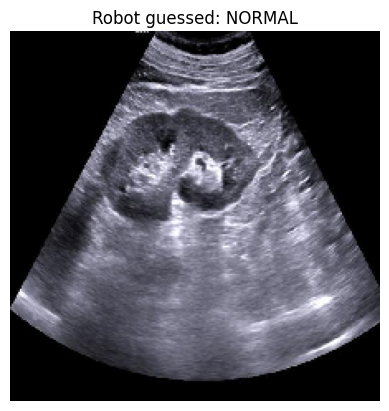

In [5]:
# --- STEP 9: THE POP QUIZ (FIXED!) ---
import numpy as np
from tensorflow.keras.preprocessing import image

print("Time for a Pop Quiz! Let's pick a picture and see what the robot guesses.")

# 1. Let's find one picture from our kidney folders
test_picture = None
for root, folders, files in os.walk(kidney_path):
    for file in files:
        # THE FIX: We tell the robot to look for .jpg, .jpeg, .png, AND .bmp!
        # We also use .lower() just in case the file name is uppercase (like picture.JPG)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            test_picture = os.path.join(root, file)
            break
    if test_picture:
        break

# We double check that the robot actually found something this time!
if test_picture is None:
    print("Uh oh! The robot still came back empty handed.")
else:
    print("Found a picture! Making the robot look at it now...")

    # 2. We load the picture and make it the exact size the robot likes (224x224)
    img = image.load_img(test_picture, target_size=(224, 224))

    # 3. We change the picture into a grid of numbers (because robots read numbers, not colors!)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # 4. Ask the robot to make a prediction!
    predictions = robot_brain.predict(img_array)

    # 5. The robot gives us two numbers. The biggest number is its final answer!
    winner_index = np.argmax(predictions[0])
    robot_answer = class_names[winner_index]

    print("\nDrumroll please... 🥁")
    print("The Robot says: I think this is... " + robot_answer.upper() + "!")

    # Let's show the picture on the screen so we can see what the robot was looking at!
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.title("Robot guessed: " + robot_answer.upper())
    plt.show()

In [6]:
# --- STEP 10: PREPARING THE BABY MONITOR FLASHCARDS ---

print("Getting the Robot's second study desk ready...")

# We use the same size (224x224) and group them by 32 again!
picture_size = (224, 224)
batch_size = 32

# Load the Baby pictures from the folder we downloaded in Step 1
print("\nLooking for Baby (Fetus) ultrasound pictures...")
baby_dataset = tf.keras.utils.image_dataset_from_directory(
    fetus_path,              # This is the baby folder
    image_size=picture_size, # Make them all the same size
    batch_size=batch_size,   # Group them by 32
    label_mode='categorical' # Read the folder names to know the answers
)

# Let's ask the robot what it found in the Baby folder!
baby_class_names = baby_dataset.class_names
print("\nThe Robot found folders for the Baby pictures! Here they are:")
for name in baby_class_names:
    print("-", name)

print("\nStep 10 Complete: The Baby flashcards are ready!")

Getting the Robot's second study desk ready...

Looking for Baby (Fetus) ultrasound pictures...
Found 6033 files belonging to 1 classes.

The Robot found folders for the Baby pictures! Here they are:
- Ultrasound Fetus Dataset

Step 10 Complete: The Baby flashcards are ready!


In [7]:
# ==========================================
# AI DOCTOR ASSISTANT: KIDNEY STONE MODEL
# ==========================================

# --- 1. IMPORT TOOLS ---
import kagglehub
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

print("Tools loaded!")

# --- 2. DOWNLOAD DATASET ---
print("Downloading Kidney Stone dataset...")
kidney_path = kagglehub.dataset_download("imtkaggleteam/kidney-stone-classification-and-object-detection")
print("Dataset saved at:", kidney_path)

# --- 3. PREPARE THE FLASHCARDS ---
picture_size = (224, 224)
batch_size = 32

print("\nOrganizing images for the Robot...")
kidney_dataset = tf.keras.utils.image_dataset_from_directory(
    kidney_path,
    image_size=picture_size,
    batch_size=batch_size,
    label_mode='categorical'
)
class_names = kidney_dataset.class_names
print("Found classes:", class_names)

# --- 4. BUILD THE ROBOT BRAIN (NEURAL NETWORK) ---
print("\nBuilding the AI Brain...")
robot_brain = models.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax') # 2 answers: Normal or Stone
])

robot_brain.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. TRAIN THE MODEL ---
print("\nStarting Training (Studying)...")
# We use 3 epochs here for speed, but you can increase this to 10 for a smarter robot!
history = robot_brain.fit(kidney_dataset, epochs=3)

# --- 6. SAVE THE BRAIN ---
model_filename = 'kidney_stone_doctor.keras'
robot_brain.save(model_filename)
print(f"\nBrain saved successfully as '{model_filename}'!")

# --- 7. POP QUIZ (TESTING) ---
print("\nRunning a quick test...")
test_picture = None
for root, folders, files in os.walk(kidney_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            test_picture = os.path.join(root, file)
            break
    if test_picture:
        break

if test_picture:
    img = image.load_img(test_picture, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = robot_brain.predict(img_array)
    winner_index = np.argmax(predictions[0])
    robot_answer = class_names[winner_index]

    print(f"\n*** TEST RESULT: The AI thinks this image is: {robot_answer.upper()} ***")

Tools loaded!
Dataset saved at: /root/.cache/kagglehub/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection/versions/1

Organizing images for the Robot...
Found 9416 files belonging to 2 classes.
Found classes: ['Normal', 'stone']

Building the AI Brain...

Starting Training (Studying)...
Epoch 1/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9885 - loss: 0.0414
Epoch 2/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 1.0000 - loss: 8.0760e-05
Epoch 3/3
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 1.0000 - loss: 2.0035e-05

Brain saved successfully as 'kidney_stone_doctor.keras'!

Running a quick test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step

*** TEST RESULT: The AI thinks this image is: NORMAL ***


In [12]:
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

# Load your trained deep learning model
model = tf.keras.models.load_model('kidney_stone_doctor.keras')

def show_output(image_path):
    # 1. Preprocessing the image for the model
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224, 224)) # Adjust based on your model's input size
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Making the Prediction
    prediction = model.predict(img_array)
    confidence = np.max(prediction) * 100

    # Mapping the result (0 = Normal, 1 = Tumor)
    result = "Tumor Detected" if np.argmax(prediction) == 1 else "Normal"

    # 3. Displaying the Visual Output
    st.header("Diagnostic Results")

    col1, col2 = st.columns(2)

    with col1:
        st.image(img, caption="Uploaded Ultrasound Image", use_column_width=True)

    with col2:
        st.subheader(f"Status: {result}")
        # Color coding for safety: Red for Tumor, Green for Normal
        color = "red" if result == "Tumor Detected" else "green"
        st.markdown(f"### Confidence: :{color}[{confidence:.2f}%]")

        if result == "Tumor Detected":
            st.warning("Action Required: Please consult a specialist for further evaluation.")
        else:
            st.success("No immediate abnormalities detected.")

# Example usage within the Streamlit app
uploaded_file = st.file_uploader("Upload Kidney Ultrasound", type=["jpg", "png", "jpeg"])
if uploaded_file is not None:
    show_output(uploaded_file)

2026-04-27 09:11:20.337 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:11:20.338 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:11:20.338 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:11:20.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:11:20.444 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-27 09:11:20.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:11:20.445 Thread 'MainThread'

In [11]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.4 MB/s eta 0:00:00


In [14]:
import streamlit as st
from PIL import Image
import numpy as np

def upload_and_process():
    st.subheader("📤 Patient Data Input")

    # STEP 1: The Upload Widget
    # We restrict types to JPG, PNG, and BMP to maintain diagnostic quality
    uploaded_file = st.file_uploader("Upload Kidney Ultrasound", type=["jpg", "png", "bmp"])

    if uploaded_file is not None:
        # STEP 2: Open the image using PIL
        img = Image.open(uploaded_file)

        # STEP 3: Display the image to the user for verification
        # This is a key part of "Integrity" - letting the doctor see what they uploaded
        st.image(img, caption="Uploaded Ultrasound Image", use_container_width=True)

        # STEP 4: Convert and Resize for the AI Model
        # We use (224, 224) as defined in your study flashcards
        img_resized = img.convert('RGB').resize((224, 224))

        # STEP 5: Convert to a Numerical Array
        # Robots read numbers, not pixels! We divide by 255.0 to normalize
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

        st.success("✅ Image processed and ready for AI analysis.")
        return img_array

    return None

# To run this in your main app:
# processed_data = upload_and_process()

In [15]:
import streamlit as st
from PIL import Image
import numpy as np

def get_medical_image():
    st.subheader("📸 Data Acquisition Portal")

    # Create two tabs: one for Uploading and one for Camera
    tab1, tab2 = st.tabs(["File Upload", "Live Camera Access"])

    with tab1:
        uploaded_file = st.file_uploader("Select Ultrasound File", type=["jpg", "png", "jpeg"])
        if uploaded_file:
            return Image.open(uploaded_file)

    with tab2:
        # st.camera_input automatically requests browser permission
        camera_file = st.camera_input("Take a photo of the Ultrasound Scan")
        if camera_file:
            return Image.open(camera_file)

    return None

# --- EXECUTION ---
img = get_medical_image()

if img is not None:
    # Display for verification (The 'Integrity' Step)
    st.image(img, caption="Image captured for AI Analysis", use_container_width=True)

    # Standardize for the Robot Brain (TensorFlow)
    img_resized = img.convert('RGB').resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    st.success("✅ Diagnostic data ready for processing.")
else:
    st.warning("Please upload a file or take a photo to begin the diagnostic process.")

2026-04-27 09:23:33.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.036 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.036 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.037 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 09:23:33.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [16]:
IMG_SIZE = 224

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        print("⚠️ Malignant (Tumor Detected)")
    else:
        print("✅ Benign (No Tumor)")